Import Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

Download Dataset

In [ ]:
import os
import kagglehub

dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

dataset = os.path.join(dataset_path, "chest_xray")

train_dir = os.path.join(dataset, "train")
test_dir = os.path.join(dataset, "test")
val_dir = os.path.join(dataset, "val")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


Parameters

In [ ]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

SEED = 42

Load Dataset

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    train_dir,

    validation_split=0.2,

    subset="training",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    train_dir,

    validation_split=0.2,

    subset="validation",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(

    test_dir,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


Class Names

In [ ]:
class_names = train_ds.class_names

print(class_names)

['NORMAL', 'PNEUMONIA']


Display Original Images

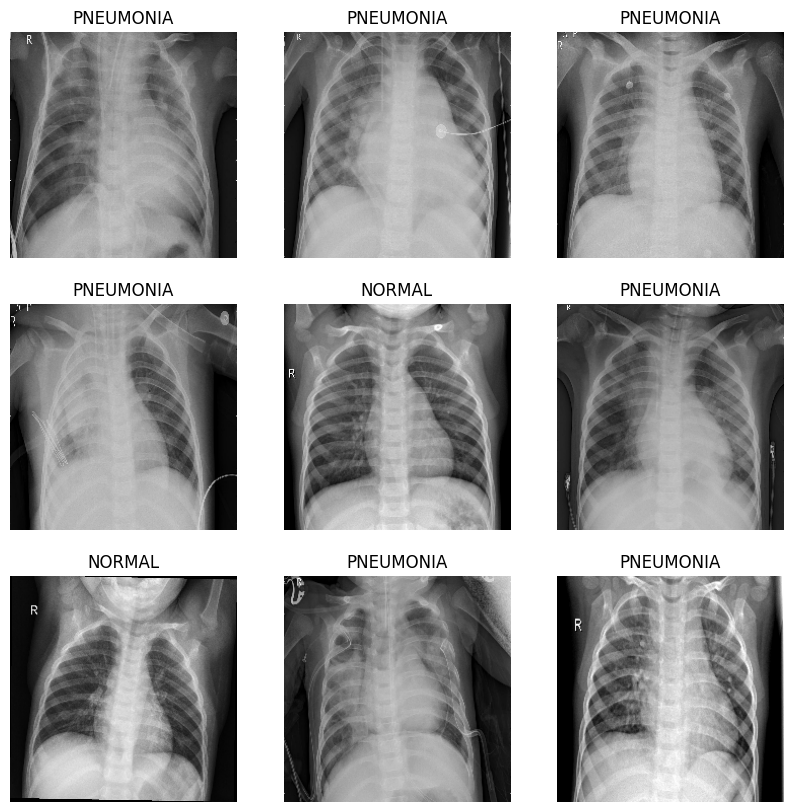

In [ ]:
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):

    for i in range(9):

        ax=plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

Data Augmentation Layer

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.08),

    tf.keras.layers.RandomZoom(0.15),

    tf.keras.layers.RandomContrast(0.15),

    tf.keras.layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    )

])

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

Show Augmented Images

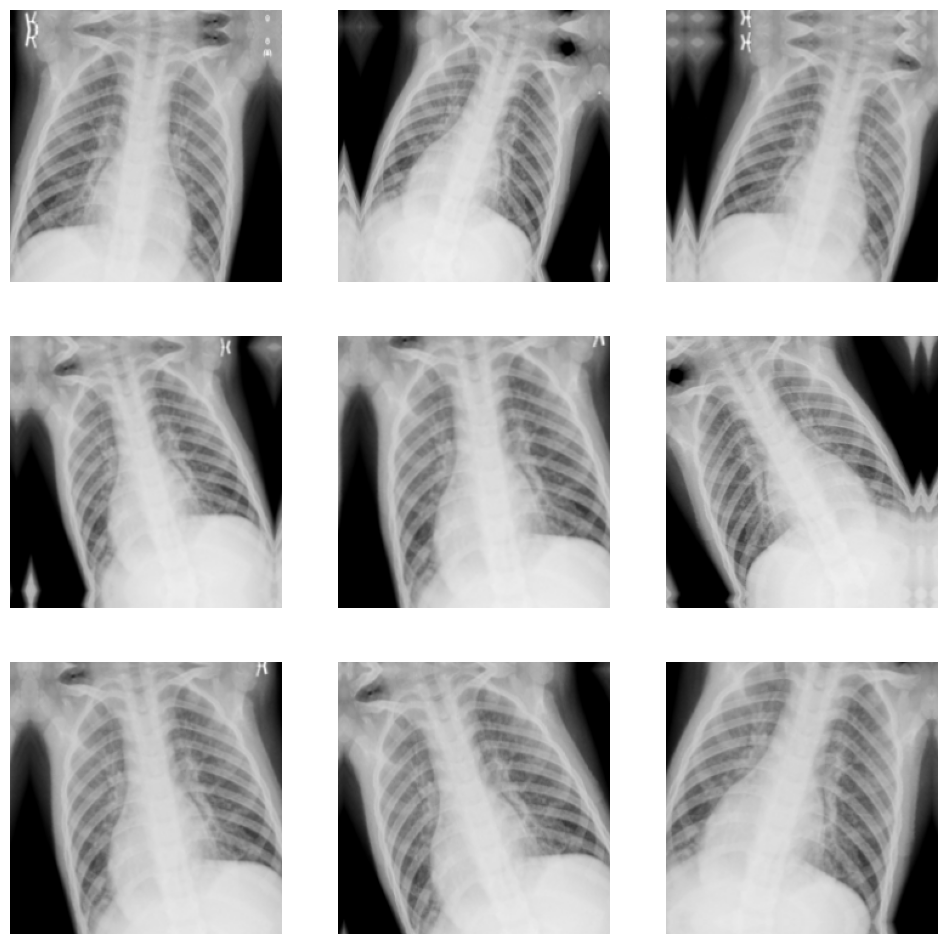

In [ ]:
plt.figure(figsize=(12,12))

for images,_ in train_ds.take(1):

    first_image=images[0]

    for i in range(9):

        ax=plt.subplot(3,3,i+1)

        augmented=data_augmentation(
            tf.expand_dims(first_image,0),
            training=True
        )

        plt.imshow(
            augmented[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.show()

Normalize Images

In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

Apply Normalization

In [ ]:
train_ds = train_ds.map(
    lambda x,y:(normalization(x),y)
)

val_ds = val_ds.map(
    lambda x,y:(normalization(x),y)
)

test_ds = test_ds.map(
    lambda x,y:(normalization(x),y)
)

Improve Performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

Verify Batch Shape

In [ ]:
for images,labels in train_ds.take(1):

    print(images.shape)

    print(labels.shape)

(32, 224, 224, 3)
(32,)


Check Pixel Range

In [ ]:
for images,_ in train_ds.take(1):

    print(images.numpy().min())

    print(images.numpy().max())

0.0
1.0


Display Final Images

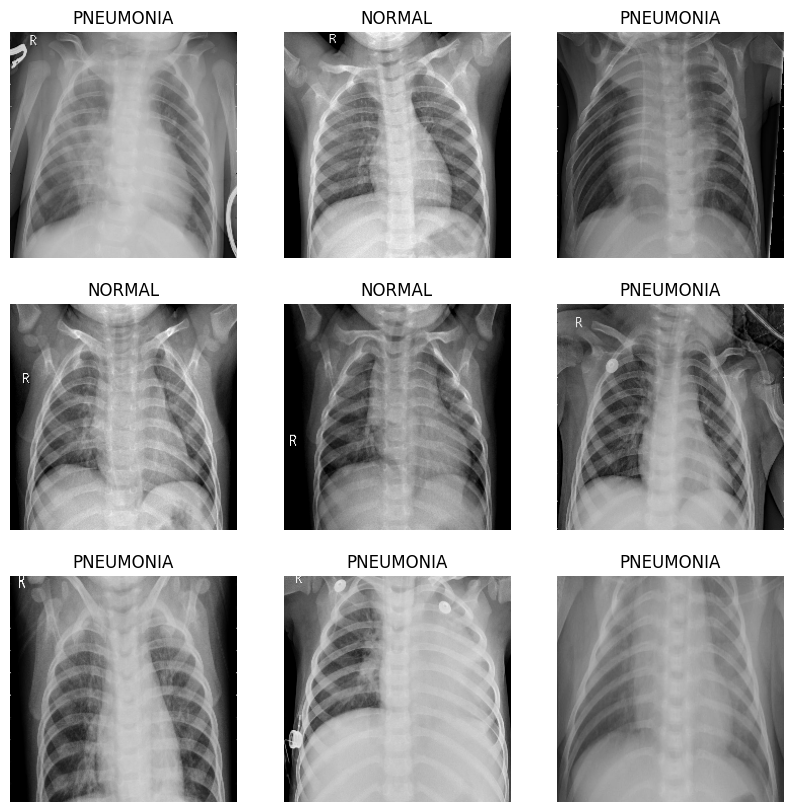

In [ ]:
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):

    for i in range(9):

        ax=plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title(class_names[labels[i]])

        plt.axis("off")

Save Configuration

In [ ]:
print("="*40)

print("Image Size :",IMG_SIZE)

print("Batch Size :",BATCH_SIZE)

print("Classes :",class_names)

print("="*40)

Image Size : (224, 224)
Batch Size : 32
Classes : ['NORMAL', 'PNEUMONIA']
